<a href="https://colab.research.google.com/github/AdityaMatrix/AdityaMatrix/blob/main/code1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 80A_3mm - Sheet1.csv to 80A_3mm - Sheet1.csv


In [ ]:
import pandas as pd

data = pd.read_csv("80A_3mm - Sheet1.csv")  # or read_csv

print(data.head())

   time    Pitch    Roll     yaw
0     0  1193.50 -426.85  199.72
1     1  1192.94 -426.25  200.84
2     2  1192.84 -462.38  200.98
3     3  1192.35 -426.09  201.38
4     4  1193.16 -424.88  201.12


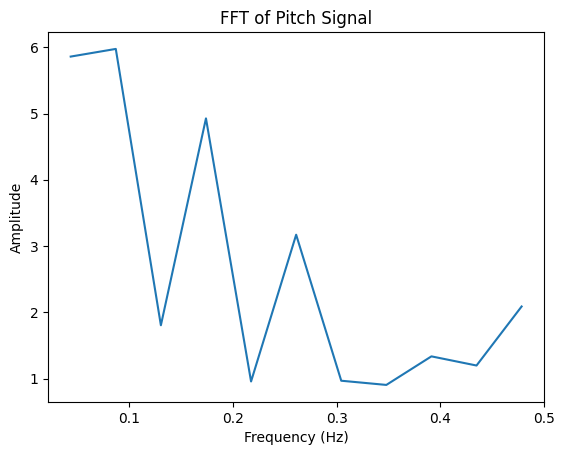

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = data['time'].values
pitch = data['Pitch'].values

# Sampling frequency
dt = time[1] - time[0]
fs = 1 / dt

# Remove mean (VERY IMPORTANT)
pitch = pitch - np.mean(pitch)

# FFT
fft_vals = np.fft.fft(pitch)
freqs = np.fft.fftfreq(len(fft_vals), dt)

# Keep positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

# Plot
plt.figure()
plt.plot(freqs, fft_vals)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of Pitch Signal")
plt.show()

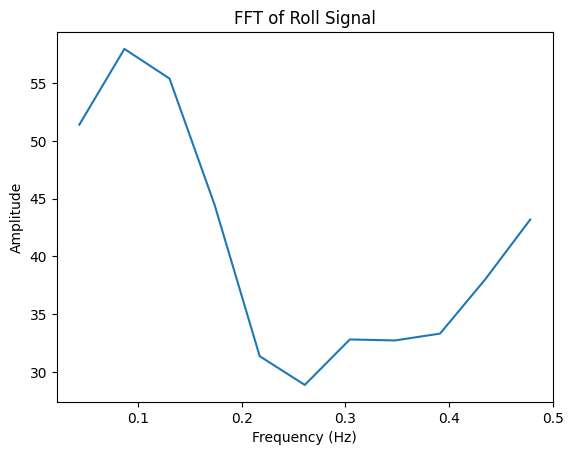

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = data['time'].values
roll = data['Roll'].values

# Sampling frequency
dt = time[1] - time[0]
fs = 1 / dt

# Remove mean
roll = roll - np.mean(roll)

# FFT
fft_vals = np.fft.fft(roll)
freqs = np.fft.fftfreq(len(fft_vals), dt)

# Keep positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

# Plot
plt.figure()
plt.plot(freqs, fft_vals)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of Roll Signal")
plt.show()

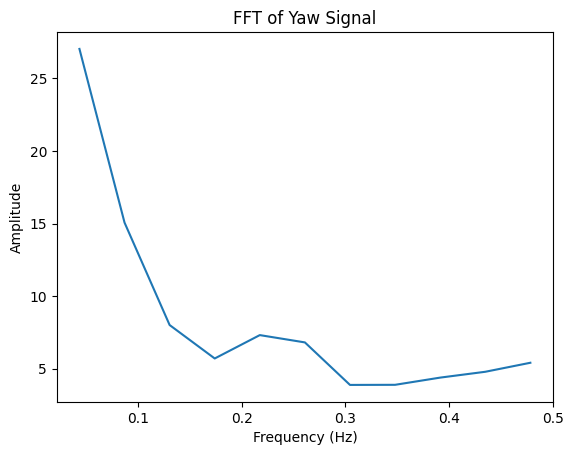

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = data['time'].values
yaw = data['yaw'].values

# Sampling frequency
dt = time[1] - time[0]
fs = 1 / dt

# Remove mean (VERY IMPORTANT)
pitch = pitch - np.mean(pitch)

# FFT
fft_vals = np.fft.fft(yaw)
freqs = np.fft.fftfreq(len(fft_vals), dt)

# Keep positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

# Plot
plt.figure()
plt.plot(freqs, fft_vals)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of Yaw Signal")
plt.show()

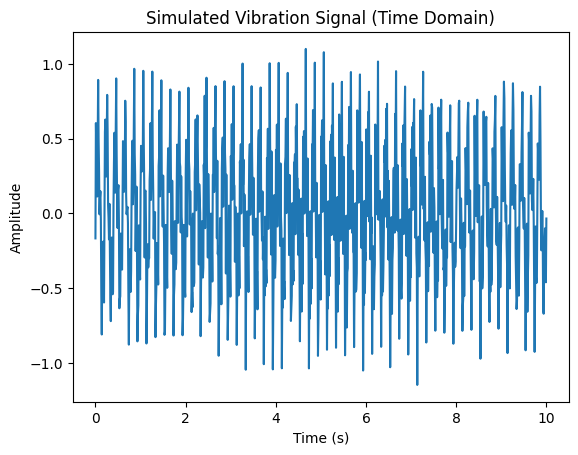

In [ ]:
#“To validate the signal processing pipeline, I generated a synthetic vibration
#signal composed of multiple frequency components and applied
#FFT to successfully identify dominant frequencies.”


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Time setup
fs = 100  # sampling frequency (Hz)
t = np.linspace(0, 10, fs*10)

# Simulated vibration signal
# Combination of multiple frequencies
signal = (
    0.5 * np.sin(2*np.pi*5*t) +    # 5 Hz (low freq - structure)
    0.3 * np.sin(2*np.pi*20*t) +   # 20 Hz (motor)
    0.2 * np.sin(2*np.pi*50*t) +   # 50 Hz (imbalance)
    0.1 * np.random.randn(len(t))  # noise
)

# Save as dataframe (optional)
data = pd.DataFrame({"Time": t, "Signal": signal})
data.to_csv("simulated_vibration.csv", index=False)

# Plot time signal
plt.figure()
plt.plot(t, signal)
plt.title("Simulated Vibration Signal (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

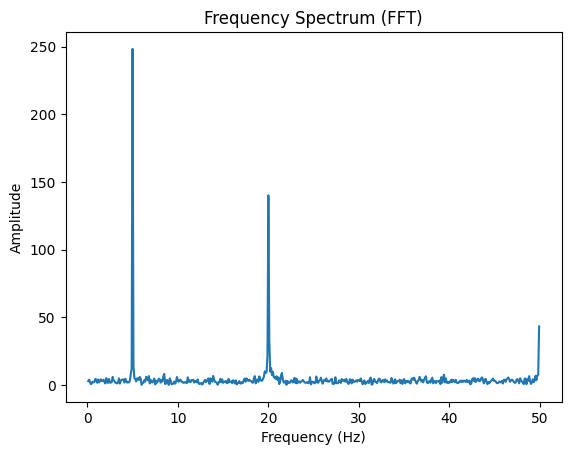

In [ ]:
# FFT
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), 1/fs)

# Keep positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

# Plot FFT
plt.figure()
plt.plot(freqs, fft_vals)
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()